- 3 subt params
- 2 pf params

In [2]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt

import pandas as pd
import seaborn as sns
import os

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

from scipy.stats import zscore

import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection

# !pip install scikit-bio

In [4]:
# pip install scikit-bio

In [5]:
from skbio.stats.distance import mantel
%matplotlib inline

In [6]:
# mixed_batch_data = pd.read_csv('/content/drive/MyDrive/curvefit_traits_merged_linearpf_onlyneccols.csv', index_col='subID')
mixed_batch_data = pd.read_csv('../../data/subtlety_playfight_data/curvefit_traits_merged_linearpf_onlyneccols_fight.csv', index_col='subID')
mixed_batch_data.drop('Unnamed: 0', axis=1, inplace=True)
mixed_batch_data

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,16.000000,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,5.000000,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,8.000000,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0


In [7]:
mixed_batch_data.isna().sum()

PSE_subt             0
range_subt           0
bias_subt            0
sigma_subt           0
PSE_pf               0
slope_pf             0
range_pf             0
bias_pf              0
social_skill         0
attn_switch          0
img                  0
attn_to_det          0
comm                 0
posAffect            0
negAffect            0
neuroticism          0
extraversion         0
openness             0
agreeableness        0
conscientiousness    0
loneliness           0
nfriends             1
dtype: int64

Looks like one subject is missing a value for `nfriends`. Let's just drop them as this will cause headaches later

In [8]:
mixed_batch_data = mixed_batch_data.dropna()
mixed_batch_data.shape

(274, 22)

In [9]:
mixed_batch_data.columns

Index(['PSE_subt', 'range_subt', 'bias_subt', 'sigma_subt', 'PSE_pf',
       'slope_pf', 'range_pf', 'bias_pf', 'social_skill', 'attn_switch', 'img',
       'attn_to_det', 'comm', 'posAffect', 'negAffect', 'neuroticism',
       'extraversion', 'openness', 'agreeableness', 'conscientiousness',
       'loneliness', 'nfriends'],
      dtype='object')

In [10]:
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf'
                 ]
trait_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'posAffect',
              'negAffect',
              'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              'loneliness',
              'nfriends'
       ]

social_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'loneliness',
              'nfriends'
              ]
personality_cols = [
                    'posAffect',
                    'negAffect',
                    'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              ]

In [11]:
results_loc= '../../results/subtlety_playfight_mixed/trait-beh/'

In [12]:
# cmap = 'BrBG'

In [13]:
# df_range_traits = pd.DataFrame(data=[[i,mixed_batch_data[i].min(),mixed_batch_data[i].max()] for i in trait_cols],columns=['trait','min','max'])
# df_range_traits

In [14]:
# df_range_traits['ticks'] = [[0,10,20,29],[0,10,20,29],[0,10,20,29],[0,10,20,29],[0,10,20,29],\
#     [0,10,20,30,40],[0,10,20,30,40], [0,20,40,60], [0,20,40,60], [0,20,40,60], [0,20,40,60], [0,20,40,60], [0,20,40,60,80],[0,10,20]]

# df_range_traits['tickends'] = [[0,29],[0,29],[0,29],[0,29],[0,29],\
#         [0,40],[0,40], 
#         [0,60],[0,60], [0,60], [0,60], [0,60],
#         [0,80],
#         [0,20]]
# df_range_traits

In [15]:
# df_range_traits['abbr'] = ['soc', 'attn', 'img','det', 'comm', 'pos', 'neg', 'N', 'E', 'O', 'A', 'C', 'UCLA', '# fr.']
# df_range_traits

In [16]:
# df_range_beh = pd.DataFrame(data=[[i,mixed_batch_data[i].min(),mixed_batch_data[i].max()] for i in curve_param_cols],columns=['param','min','max'])
# df_range_beh['ylabel'] = [i.split('_')[0] for i in df_range_beh['param']]
# df_range_beh

In [17]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [18]:
# fig, axes = plt.subplots(nrows=len(curve_param_cols), ncols = len(trait_cols), figsize=(25,10),sharey=True,sharex='col')

# all_ps = []

# for i,param in enumerate(curve_param_cols):
#     for j,trait in enumerate(trait_cols):
#         x = trait
#         y = param
#         r, p = sp.stats.pearsonr(mixed_batch_data[x], mixed_batch_data[y])
#         all_ps.append(p)

#         if p < 0.05:
#             # color = 'black'
#             weight = 'bold'
#             alpha = 1
#             fontsize = 20
#             linewidth = 1
#         else:
#             # color = 'gray'
#             weight = None
#             alpha = .1
#             fontsize = 16
#             linewidth = 1

#         if i <= 2:
#             color = 'tab:blue'
#         else:
#             color = 'tab:red'


#         sns.regplot(data=mixed_batch_data, x=x, y=y, ax=axes[i,j], color=color, scatter_kws={'s':2,'alpha':alpha},line_kws={'alpha': alpha, 'linewidth' : linewidth})
        
#         axes[i,j].annotate(f'r={r:.2f}', xy=(1, 0), xycoords = 'axes fraction', weight = weight,fontsize=fontsize,va='bottom',ha='right')

#         axes[i,j].set_xlabel('') 
        
#         if j == 0:
#             ylabel = df_range_beh.loc[df_range_beh['param']==param,'ylabel'].values[0]
#             print(ylabel, len(ylabel))
#             axes[i,j].set_ylabel(ylabel, fontsize=20,color=color,fontweight='bold')
#         else:
#             axes[i,j].set_ylabel('')

#         if i == 0:
#             title = df_range_traits.loc[df_range_traits['trait']==trait,'abbr'].values[0]
#             axes[i,j].set_title(title, fontweight='bold',color='k',fontsize=20)
#         else:
#             axes[i,j].set_title('')
        
#         row = df_range_traits['trait'] == trait
#         xmin,xmax = df_range_traits.loc[row,'min'].values[0],df_range_traits.loc[row,'max'].values[0]
#         axes[i,j].set_xlim(xmin,xmax)
#         axes[i,j].set_xticks(df_range_traits.loc[row,'tickends'].values[0])

# fig.tight_layout()
# plt.savefig(f'{results_loc}/trait_beh_all_scatter_long.png', dpi=300, bbox_inches='tight')

In [19]:
# fdrcorrection(all_ps)

In [20]:
mixed_batch_data

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,16.000000,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,5.000000,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,8.000000,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0


In [21]:
# first, super important to z-score all the features in order to minimize the impact of different features being measured on different scales (just like PCA)
mixed_batch_data_zscored = mixed_batch_data.apply(zscore)
mixed_batch_data_zscored

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,1.587100,1.139946,-2.182466,0.144545,-0.206179,0.740744,0.802900,0.052813,1.249255,1.403779,...,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,-0.836964,0.619923,1.390323,-0.452518,2.089832,-0.732085,-0.731401,-0.970100,1.249255,0.813345,...,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,-0.453342,0.095984,0.670868,0.414827,-0.278646,1.011263,1.084710,0.192006,0.604630,2.584649,...,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,0.813243,1.624863,0.816307,-0.399448,1.248505,0.227830,0.268579,-1.585944,-0.845776,-1.154772,...,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-0.413524,-0.604109,-0.212045,1.704615,0.843637,-0.536710,-0.527871,-0.447886,-1.329245,-0.170714,...,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,0.876526,-0.335034,-0.276210,-0.256498,0.258657,2.216193,0.419721,...,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.903194,0.770473,1.393153,-1.871185,0.603566,0.726018,0.787560,-1.585402,0.282318,-0.367525,...,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.479799,1.682444,1.192794,-1.161440,-0.847731,0.750763,0.813338,1.392306,0.443474,1.797403,...,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


In [22]:
bias_PSE_subt_diff = mixed_batch_data_zscored['bias_subt'] - mixed_batch_data_zscored['PSE_subt']
bias_PSE_pf_diff = mixed_batch_data_zscored['bias_pf'] - mixed_batch_data_zscored['PSE_pf']

mixed_batch_data_zscored.insert(3, 'bias_PSE_subt_diff', bias_PSE_subt_diff)
mixed_batch_data_zscored.insert(9, 'bias_PSE_pf_diff', bias_PSE_pf_diff)
mixed_batch_data_zscored

,PSE_subt,range_subt,bias_subt,bias_PSE_subt_diff,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,bias_PSE_pf_diff,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,1.587100,1.139946,-2.182466,-3.769566,0.144545,-0.206179,0.740744,0.802900,0.052813,0.258992,...,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,-0.836964,0.619923,1.390323,2.227287,-0.452518,2.089832,-0.732085,-0.731401,-0.970100,-3.059932,...,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,-0.453342,0.095984,0.670868,1.124210,0.414827,-0.278646,1.011263,1.084710,0.192006,0.470651,...,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,0.813243,1.624863,0.816307,0.003064,-0.399448,1.248505,0.227830,0.268579,-1.585944,-2.834449,...,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-0.413524,-0.604109,-0.212045,0.201478,1.704615,0.843637,-0.536710,-0.527871,-0.447886,-1.291524,...,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,0.415964,0.876526,-0.335034,-0.276210,-0.256498,0.258657,0.593691,...,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.903194,0.770473,1.393153,0.489960,-1.871185,0.603566,0.726018,0.787560,-1.585402,-2.188969,...,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.479799,1.682444,1.192794,0.712995,-1.161440,-0.847731,0.750763,0.813338,1.392306,2.240037,...,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


In [23]:
curve_param_cols

['PSE_subt', 'range_subt', 'bias_subt', 'range_pf', 'bias_pf']

# IS-RSA

In [24]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [25]:
def plot_is_rsa(results_df, filename, title):
    fig,axs = plt.subplots(nrows=1,ncols=1,figsize=(10,5))
    plots = sns.barplot(dodge=False,
        x="task", 
        y="r", 
        data=results_df.reset_index(), 
        hue="task", 
        palette=['purple', 'tab:blue', 'tab:red'], 
    # Adjust this value to increase or decrease the bar width
    )

    count = -1
    for b, bar in enumerate(plots.patches):
        if ~np.isnan(bar.get_height()):  # Ensure index doesn't go out of bounds
            count+=1
            print(b,bar)
            # annotate bar with r and p value
            r = results_df.iloc[count]['r']#[b, 0]
            p = results_df.iloc[count]['p']#[b, 1]

            print('bar.get_x():',bar.get_x())

            if p < 0.05:
                weight='bold'
                annot='*'
            else:
                weight=None
                annot=' (n.s.)'
            
            plots.annotate(f'r = {r:.3f} \np = {p:.3f} {annot}',
                            (bar.get_x() + bar.get_width() / 2,
                            bar.get_height()*1.01), ha='center', va='bottom',
                            size=16, xytext=(0, 12),
                            textcoords='offset points',
                            weight=weight)

        plots.set_ylabel("IS-RSA $r$ value")
        plots.set_ylim(0, 0.08)
        plots.set_xlabel('')
        xticks = plots.get_xticks()
        plots.set_title(title, fontweight='bold',color='k')
        # plots.legend(None)#bbox_to_anchor=[1.01,1])
        # plots.get_legend().remove()
        plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
        # plt.savefig(f'{results_loc}/trait_beh_comparisons.png', dpi=300, bbox_inches='tight')
        plt.savefig(filename, dpi=300, bbox_inches='tight')

In [26]:
def compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols):
    # compute the IS-RSA
    # All curve params (both tasks), all traits
    results_dict = {}
    
    x = sp.spatial.distance.pdist(mixed_batch_data_zscored[curve_param_cols], 'euclidean')
    y = sp.spatial.distance.pdist(mixed_batch_data_zscored[trait_cols], 'euclidean')
    r, p, n = mantel(x, y, method='pearson', alternative='greater', permutations=10000)#5000)
    print(f'r = {r:.3f}, p = {p:.3f}, n = {n}')
    results_dict['both'] = (r, p)

    # Just subtlety params, all traits
    x = sp.spatial.distance.pdist(mixed_batch_data_zscored[subt_param_cols], 'euclidean')
    y = sp.spatial.distance.pdist(mixed_batch_data_zscored[trait_cols], 'euclidean')
    r, p, n = mantel(x, y, method='pearson', alternative='greater', permutations=10000)#5000)
    print(f'r = {r:.3f}, p = {p:.3f}, n = {n}')
    results_dict['subt_only'] = (r, p)

    # Just playfight params, all traits
    x = sp.spatial.distance.pdist(mixed_batch_data_zscored[pf_param_cols], 'euclidean')
    y = sp.spatial.distance.pdist(mixed_batch_data_zscored[trait_cols], 'euclidean')
    r, p, n = mantel(x, y, method='pearson', alternative='greater', permutations=10000)#5000)
    print(f'r = {r:.3f}, p = {p:.3f}, n = {n}')
    results_dict['pf_only'] = (r, p)

    results_df = pd.DataFrame.from_dict(results_dict, orient='index', columns=['r', 'p'])
    results_df.index.name = 'task'
    return results_df

r = 0.051, p = 0.054, n = 274
r = 0.026, p = 0.198, n = 274
r = 0.046, p = 0.055, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0510811, angle=0)
bar.get_x(): -0.4


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0261623, angle=0)
bar.get_x(): 0.6
2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0460179, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.051081,0.054195
subt_only,0.026162,0.197680
pf_only,0.046018,0.055294


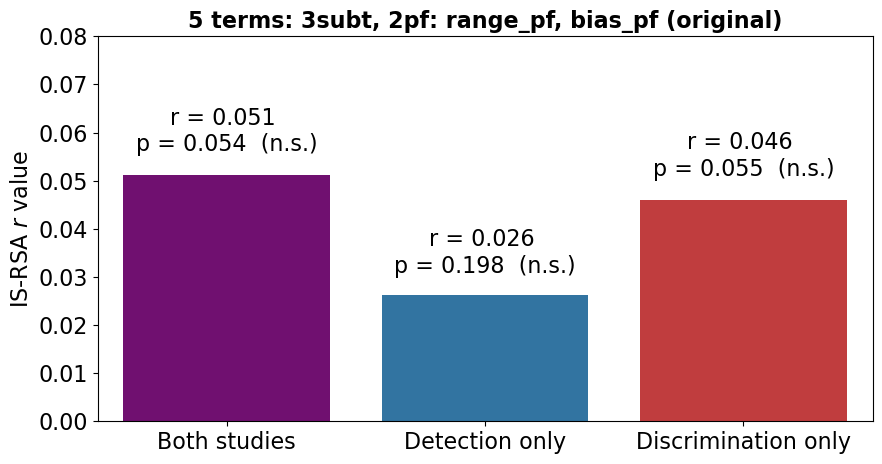

In [27]:
# v1 - OG terms
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf'
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_ogtraits.png', '5 terms: 3subt, 2pf: range_pf, bias_pf (original)')
results_df

r = 0.050, p = 0.059, n = 274
r = 0.026, p = 0.200, n = 274
r = 0.039, p = 0.102, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0504916, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0261623, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0388195, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.050492,0.058894
subt_only,0.026162,0.199980
pf_only,0.038819,0.101790


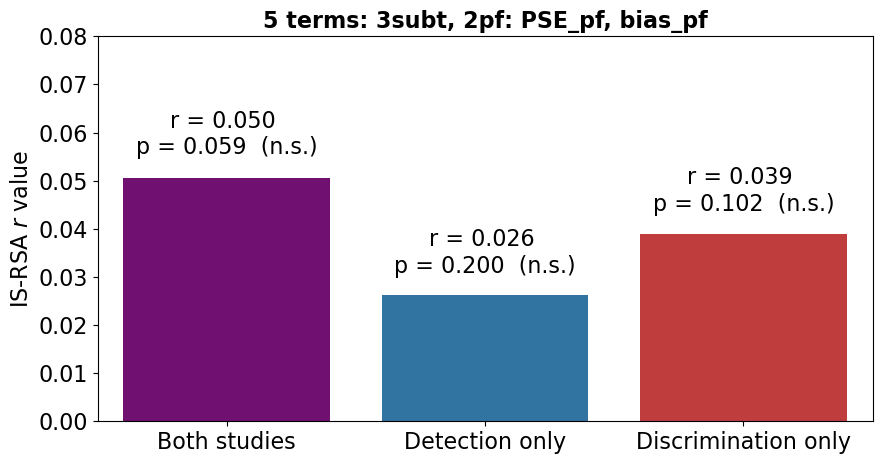

In [28]:
# v2
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  # 'range_pf',
                  'bias_pf',
                  'PSE_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                #  'range_pf',
                 'bias_pf',
                 'PSE_pf'
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_withPSE.png', '5 terms: 3subt, 2pf: PSE_pf, bias_pf')
results_df

r = 0.046, p = 0.069, n = 274
r = 0.026, p = 0.197, n = 274
r = 0.032, p = 0.148, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.046411, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0261623, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0315248, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.046411,0.069293
subt_only,0.026162,0.197180
pf_only,0.031525,0.148485


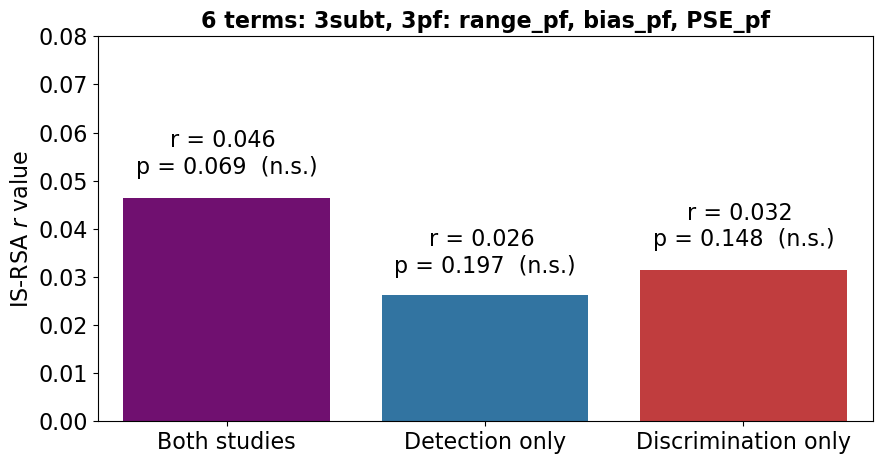

In [29]:
# v3
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf',
                  'PSE_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf',
                 'PSE_pf'
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_withPSE_and_range.png', '6 terms: 3subt, 3pf: range_pf, bias_pf, PSE_pf')
results_df

r = 0.047, p = 0.062, n = 274
r = 0.033, p = 0.150, n = 274
r = 0.024, p = 0.187, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0470546, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0332655, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0241017, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.047055,0.061894
subt_only,0.033265,0.149885
pf_only,0.024102,0.187481


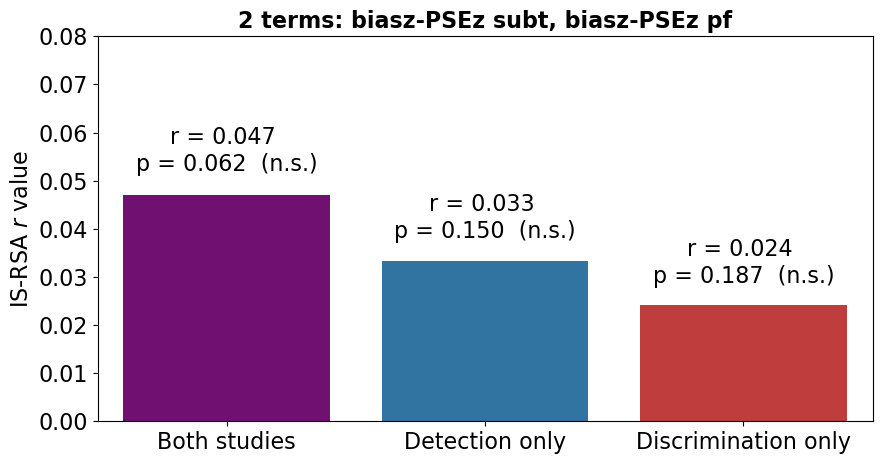

In [30]:
# v4
curve_param_cols = [
                  'bias_PSE_subt_diff',
                  'bias_PSE_pf_diff'
                    ]
subt_param_cols = [
                  'bias_PSE_subt_diff'
                   ]
pf_param_cols = [
                 'bias_PSE_pf_diff'
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_only_bias-PSE_diffterm.png', '2 terms: biasz-PSEz subt, biasz-PSEz pf')
results_df

r = 0.044, p = 0.077, n = 274
r = 0.027, p = 0.195, n = 274
r = 0.025, p = 0.180, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0436339, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0274159, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0251548, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.043634,0.076892
subt_only,0.027416,0.194581
pf_only,0.025155,0.179682


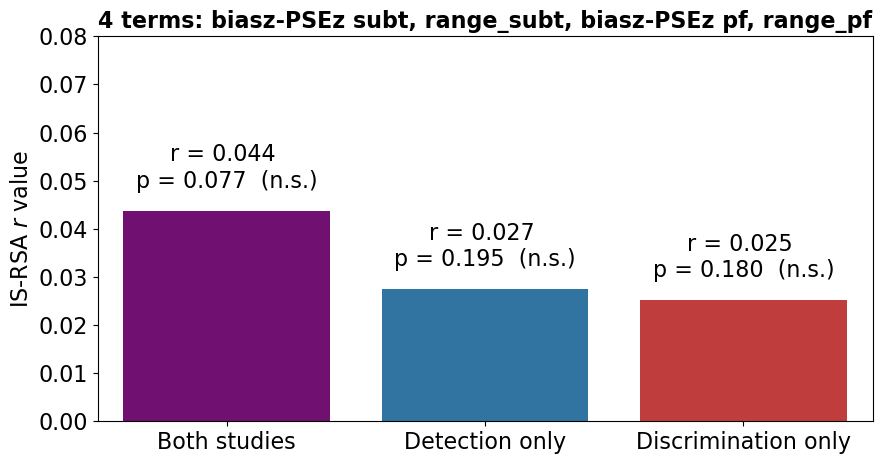

In [31]:
# v5
curve_param_cols = [
                  'bias_PSE_subt_diff',
                  'range_subt',
                  'bias_PSE_pf_diff',
                  'range_pf'
                    ]
subt_param_cols = [
                  'bias_PSE_subt_diff',
                  'range_subt',
                   ]
pf_param_cols = [
                 'bias_PSE_pf_diff',
                 'range_pf'
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_bias-PSE_diffterm_range.png', '4 terms: biasz-PSEz subt, range_subt, biasz-PSEz pf, range_pf')
results_df

r = 0.057, p = 0.037, n = 274
r = 0.033, p = 0.147, n = 274
r = 0.058, p = 0.021, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0574511, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0332655, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0575566, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.057451,0.036896
subt_only,0.033265,0.147285
pf_only,0.057557,0.020998


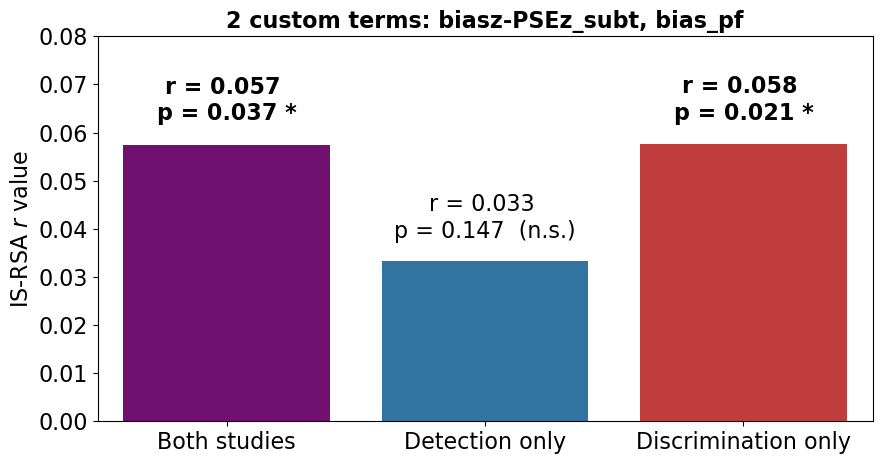

In [32]:
# v6
curve_param_cols = [
                  'bias_PSE_subt_diff',
                #   'range_subt',
                #   'bias_PSE_pf_diff',
                'bias_pf',
                  # 'range_pf'
                    ]
subt_param_cols = [
                  'bias_PSE_subt_diff',
                #   'range_subt',
                   ]
pf_param_cols = [
                #  'bias_PSE_pf_diff',
                'bias_pf',
                # 'range_pf'
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_subtbias-PSE_diffterm_pfrange.png', '2 custom terms: biasz-PSEz_subt, bias_pf')
results_df

# last 4

r = 0.047, p = 0.061, n = 274
r = 0.033, p = 0.139, n = 274
r = 0.024, p = 0.184, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0470546, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0332655, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0241017, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.047055,0.061494
subt_only,0.033265,0.139486
pf_only,0.024102,0.183882


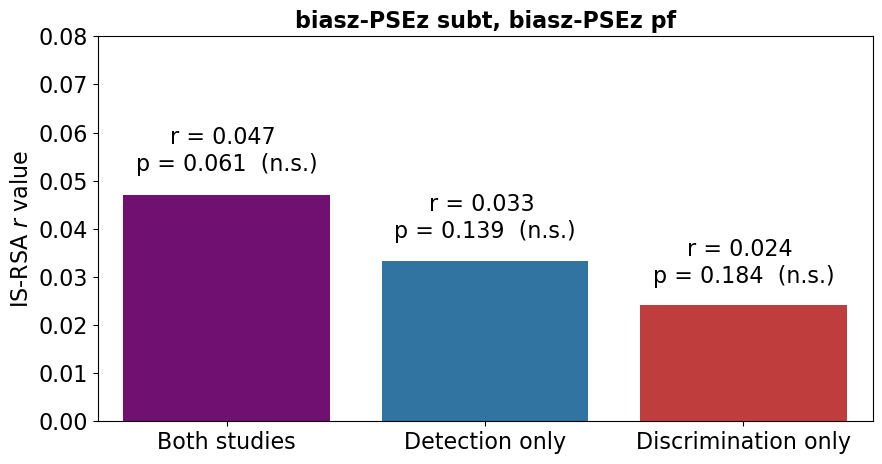

In [38]:
# v6
curve_param_cols = [
                'bias_PSE_subt_diff',
                'bias_PSE_pf_diff',
                    ]
subt_param_cols = [
                'bias_PSE_subt_diff',
                   ]
pf_param_cols = [
                'bias_PSE_pf_diff',
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_only_bias-PSE_both.png', 'biasz-PSEz subt, biasz-PSEz pf')
results_df

r = 0.006, p = 0.395, n = 274
r = 0.002, p = 0.459, n = 274
r = 0.003, p = 0.441, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.00623083, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.00203894, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.00301854, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.006231,0.394761
subt_only,0.002039,0.458854
pf_only,0.003019,0.441256


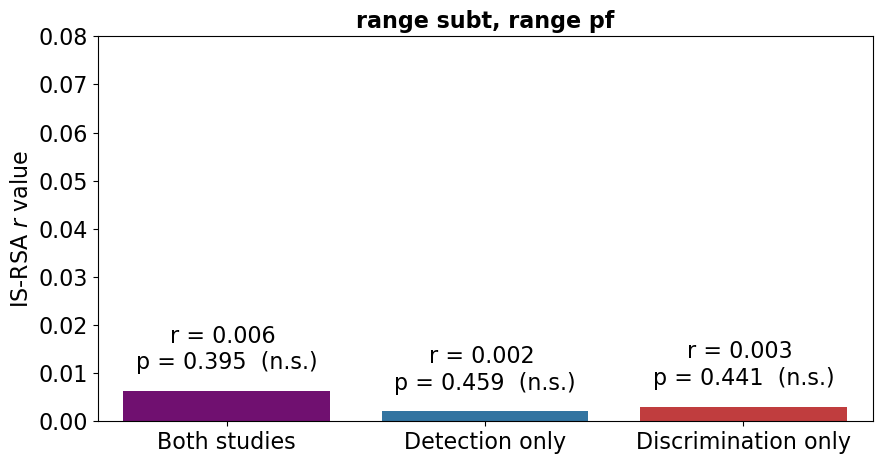

In [40]:
# v6
curve_param_cols = [
                'range_subt',
                'range_pf',
                    ]
subt_param_cols = [
                'range_subt',
                   ]
pf_param_cols = [
                'range_pf',
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_only_range_both.png', 'range subt, range pf')
results_df

r = 0.044, p = 0.080, n = 274
r = 0.027, p = 0.193, n = 274
r = 0.025, p = 0.179, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0436339, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0274159, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.0251548, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.043634,0.080292
subt_only,0.027416,0.193081
pf_only,0.025155,0.179382


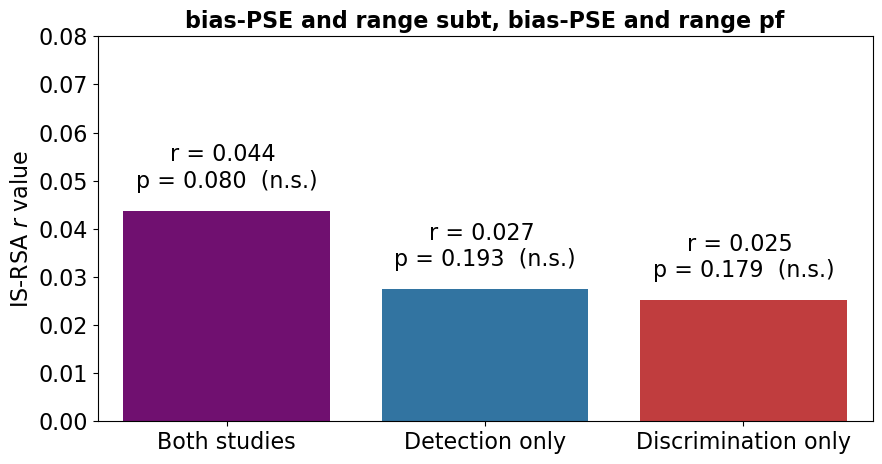

In [41]:
# v6
curve_param_cols = [
                'bias_PSE_subt_diff',
                'bias_PSE_pf_diff',
                'range_subt',
                'range_pf',
                    ]
subt_param_cols = [
                'bias_PSE_subt_diff',
                'range_subt',
                   ]
pf_param_cols = [
                'bias_PSE_pf_diff',
                'range_pf',
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_bias-PSE_range_both.png', 'bias-PSE and range subt, bias-PSE and range pf')
results_df

r = 0.034, p = 0.144, n = 274
r = 0.033, p = 0.148, n = 274
r = 0.003, p = 0.447, n = 274
0 Rectangle(xy=(-0.4, 0), width=0.8, height=0.0339329, angle=0)
bar.get_x(): -0.4
1 Rectangle(xy=(0.6, 0), width=0.8, height=0.0332655, angle=0)
bar.get_x(): 0.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])
/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


2 Rectangle(xy=(1.6, 0), width=0.8, height=0.00301854, angle=0)
bar.get_x(): 1.6


/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_13593/3042489864.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plots.set_xticklabels(['Both studies','Detection only','Discrimination only'])


,r,p
task,,
both,0.033933,0.144286
subt_only,0.033265,0.147585
pf_only,0.003019,0.447355


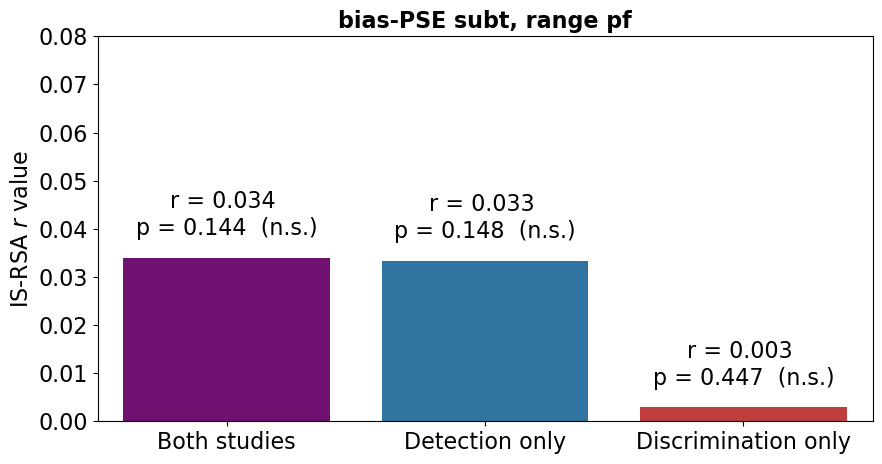

In [42]:
# v6
curve_param_cols = [
                'bias_PSE_subt_diff',
                'range_pf',
                    ]
subt_param_cols = [
                'bias_PSE_subt_diff',
                   ]
pf_param_cols = [
                'range_pf',
                 ]

results_df = compute_rsa(mixed_batch_data_zscored, trait_cols, curve_param_cols)
plot_is_rsa(results_df, f'{results_loc}/trait_beh_comparisons_bias-PSE_subt_range_pf.png', 'bias-PSE subt, range pf')
results_df

In [ ]:
cmap = 'BrBG'#'RdBu_r'

In [ ]:
data = mixed_batch_data_zscored[[
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf',
                  'PSE_pf'
                    ]]
mask = np.triu(np.ones_like(data.corr(), dtype=bool))
sns.heatmap(data.corr(), cmap=cmap, mask =mask, annot=True, fmt='.2f', vmin=-1,vmax=1)